In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits

digits_data = load_digits()
df = pd.DataFrame(data=digits_data.data, columns=digits_data.feature_names)
df['target'] = digits_data.target

print(f"Data Loaded Successfully from Scikit-Learn.")
print(f"Full Dataset Shape: {df.shape} (1797 rows, 65 columns)")

df.iloc[:, :5].head()

Data Loaded Successfully from Scikit-Learn.
Full Dataset Shape: (1797, 65) (1797 rows, 65 columns)


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4
0,0.0,0.0,5.0,13.0,9.0
1,0.0,0.0,0.0,12.0,13.0
2,0.0,0.0,0.0,4.0,15.0
3,0.0,0.0,7.0,15.0,13.0
4,0.0,0.0,0.0,1.0,11.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete.")
print(f"Train Shape: {X_train_scaled.shape}, Test Shape: {X_test_scaled.shape}")

Preprocessing Complete.
Train Shape: (1437, 64), Test Shape: (360, 64)


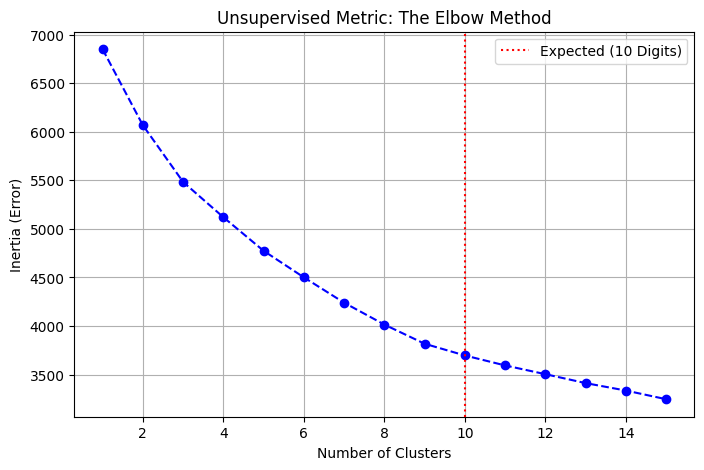

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Test cluster counts from 1 to 15
inertia = []
k_range_unsupervised = range(1, 16)
for k in k_range_unsupervised:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range_unsupervised, inertia, marker='o', linestyle='--', color='blue')
plt.title('Unsupervised Metric: The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Error)')
plt.axvline(x=10, color='red', linestyle=':', label='Expected (10 Digits)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np

clusterer = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = clusterer.fit_predict(X_train_scaled)

silhouette_avg = silhouette_score(X_train_scaled, cluster_labels)
print(f"For n_clusters = 10, the average silhouette_score is: {silhouette_avg:.3f}")
sample_silhouette_values = silhouette_samples(X_train_scaled, cluster_labels)

For n_clusters = 10, the average silhouette_score is: 0.183


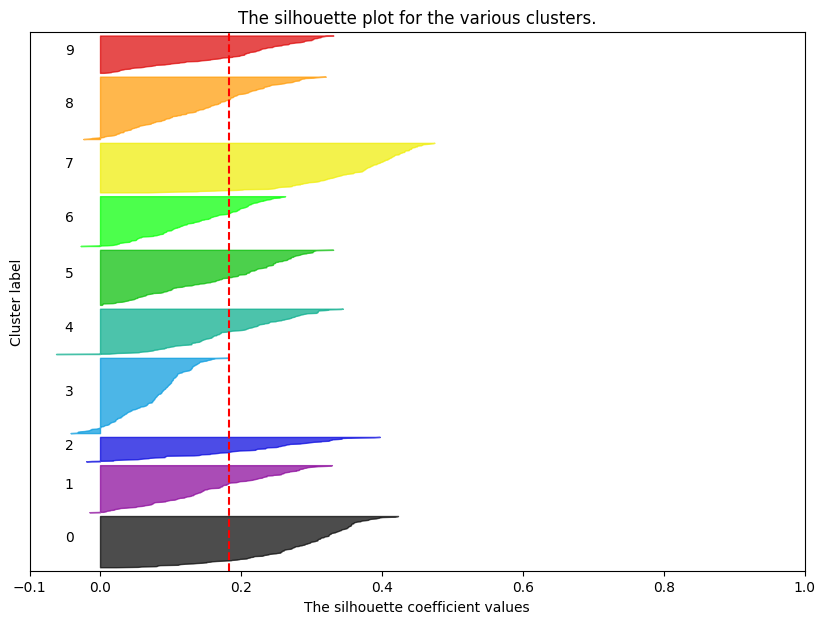

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(10, 7)
ax1.set_ylim([0, len(X_train_scaled) + (10 + 1) * 10])
y_lower = 10
for i in range(10):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / 10)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.show()

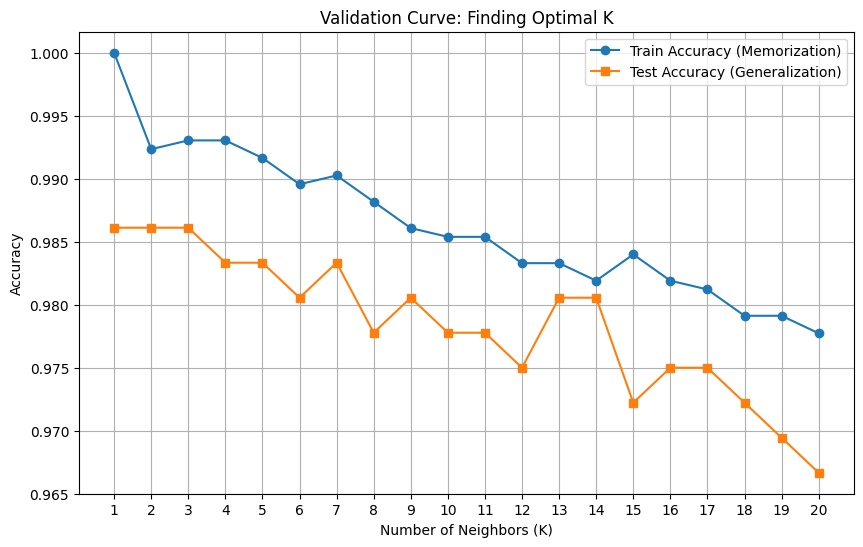

The Best K Value is: 1


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

train_scores = []
test_scores = []
k_range_supervised = range(1, 21)
for k in k_range_supervised:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

# Validation Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range_supervised, train_scores, label='Train Accuracy (Memorization)', marker='o')
plt.plot(k_range_supervised, test_scores, label='Test Accuracy (Generalization)', marker='s')
plt.title('Validation Curve: Finding Optimal K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_range_supervised)
plt.legend()
plt.grid(True)
plt.show()

best_k = k_range_supervised[test_scores.index(max(test_scores))]
print(f"The Best K Value is: {best_k}")

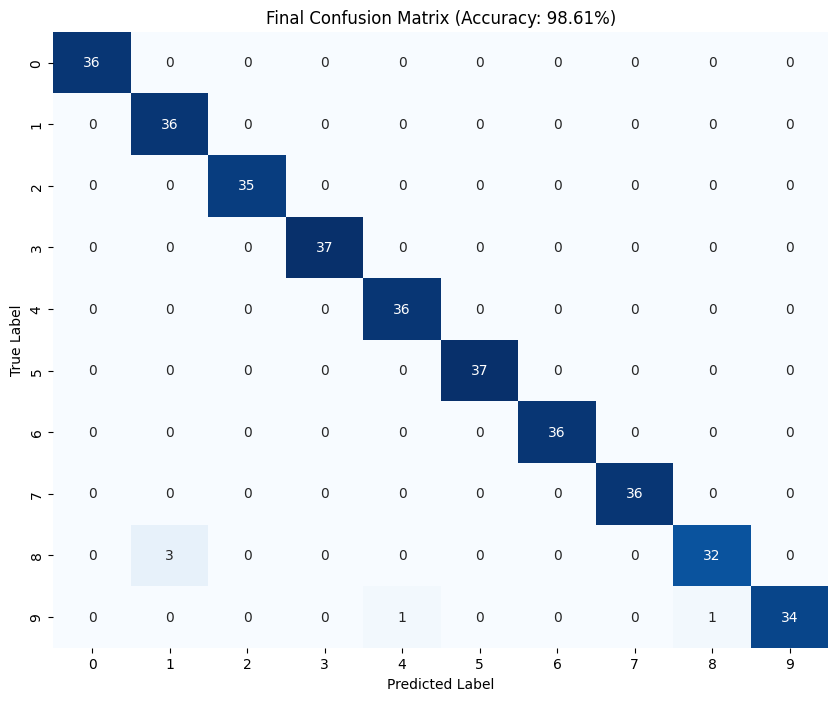

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
final_acc = final_model.score(X_test_scaled, y_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Final Confusion Matrix (Accuracy: {final_acc:.2%})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

In [ ]:
import numpy as np

total_test = len(y_test)
mistakes_mask = y_test != y_pred
mistake_indices = y_test.index[mistakes_mask]
total_mistakes = len(mistake_indices)
total_correct = total_test - total_mistakes
accuracy_percent = (total_correct / total_test) * 100

print(f"FINAL MODEL PERFORMANCE REPORT")
print(f" Total Images Tested:   {total_test}")
print(f" Correct Predictions:   {total_correct} (Perfect)")
print(f" Wrong Predictions:     {total_mistakes} (Edge Cases)")
print(f" Final Accuracy Score:  {accuracy_percent:.2f}%")

FINAL MODEL PERFORMANCE REPORT
 Total Images Tested:   360
 Correct Predictions:   355 (Perfect)
 Wrong Predictions:     5 (Edge Cases)
 Final Accuracy Score:  98.61%



DISPLAYING ONLY THE FEW ERRORS BELOW (To analyze why they failed):


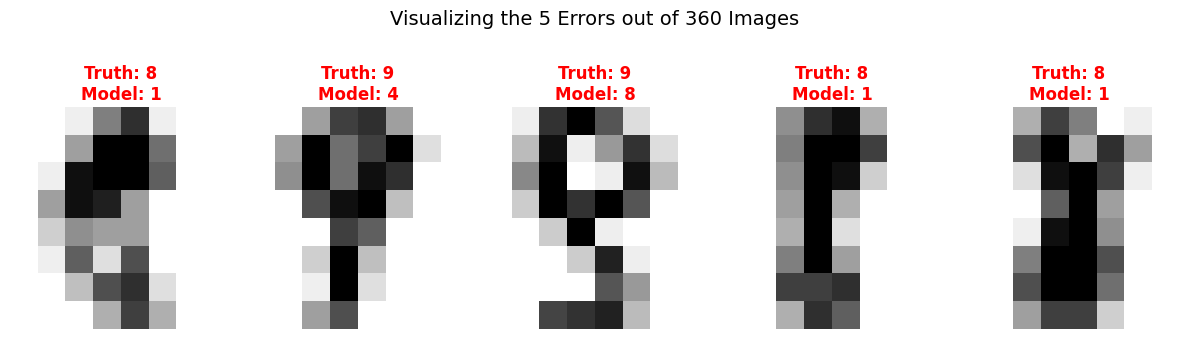

In [ ]:
import matplotlib.pyplot as plt

print("\nDISPLAYING ONLY THE FEW ERRORS BELOW (To analyze why they failed):")
num_to_show = min(5, total_mistakes)
if num_to_show > 0:
    plt.figure(figsize=(12, 4))

    for i in range(num_to_show):
        index = mistake_indices[i]
        image_pixels = X_test.loc[index].values.reshape(8, 8)
        true_label = y_test.loc[index]
        pred_label = y_pred[np.where(y_test.index == index)[0][0]]

        plt.subplot(1, num_to_show, i + 1)
        plt.imshow(image_pixels, cmap=plt.cm.gray_r, interpolation='nearest')
        plt.title(f'Truth: {true_label}\nModel: {pred_label}', color='red', fontweight='bold')
        plt.axis('off')

    plt.suptitle(f"Visualizing the {total_mistakes} Errors out of {total_test} Images", fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("The model made 0 mistakes! 100% Accuracy.")

THE SUCCESSFUL PREDICTIONS


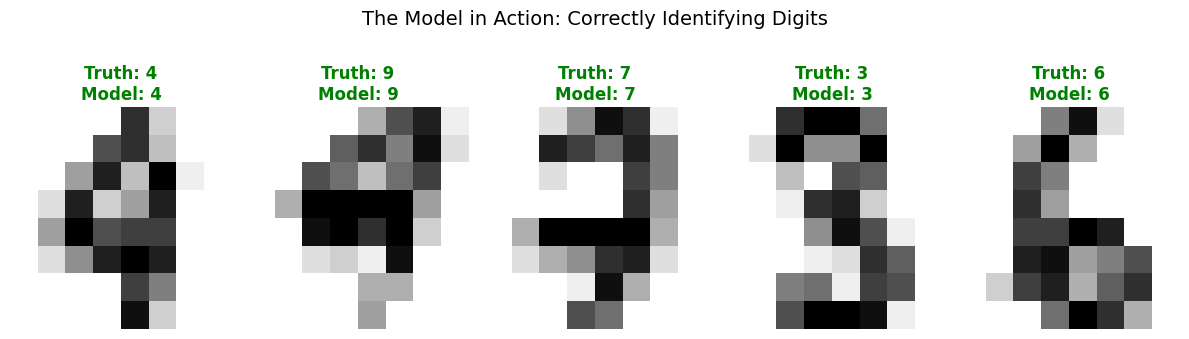

   Final Accuracy: 98.61%


In [ ]:
import random

correct_mask = y_test == y_pred
correct_indices = y_test.index[correct_mask]
random_indices = random.sample(list(correct_indices), 5)

print(f"THE SUCCESSFUL PREDICTIONS")

plt.figure(figsize=(12, 4))

for i, index in enumerate(random_indices):
    image_pixels = X_test.loc[index].values.reshape(8, 8)

    true_label = y_test.loc[index]
    pred_label = y_pred[np.where(y_test.index == index)[0][0]]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image_pixels, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Truth: {true_label}\nModel: {pred_label}', color='green', fontweight='bold')
    plt.axis('off')

plt.suptitle("The Model in Action: Correctly Identifying Digits", fontsize=14)
plt.tight_layout()
plt.show()

print(f"   Final Accuracy: {accuracy_percent:.2f}%")